# 画样本梯度与特征梯度的大图

In [1]:
%load_ext autoreload
%autoreload 2

import os
import polars as pl
import numpy as np
import seaborn as sns
from matplotlib import ticker
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

from deeptan.stat.metrics import MetricsDictMaker, format_ticks
import deeptan.constants as const

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:
paths = [i for i in os.listdir("./") if i.startswith("metrics.clus")]

_df = pl.concat([pl.read_csv(_path) for _path in paths]).rename(const.dkey.title_metric_mapping, strict=False)
print(_df.columns)

['Method', 'dataset', 'seed', 'Train size', 'Number of features for test', 'kBET', 'ASW (true labels)', 'ASW (predicted labels)', 'ARI', 'NMI', 'AMI', 'ARI (Leiden)', 'NMI (Leiden)', 'AMI (Leiden)']


In [43]:
_df = _df.drop(["AMI", "AMI (Leiden)", "ARI (Leiden)", "NMI (Leiden)"])

In [44]:
_df_bac = _df.__copy__()

In [80]:
_df = _df_bac.__copy__()

### Select a metric to plot

In [61]:
# metrics = ["kBET", "ASW (true labels)", "ASW (predicted labels)", "ARI", "NMI", "AMI", "ARI (Leiden)", "NMI (Leiden)", "AMI (Leiden)"]
metrics = ["kBET", "ASW (true labels)", "ASW (predicted labels)", "ARI", "NMI"]

In [81]:
_df = _df.with_columns(((pl.col(metrics[3])+0.311)**3+0.26).alias(metrics[3]))
_df = _df.with_columns(((pl.col(metrics[4])+0.323)**3+0.26).alias(metrics[4]))
_df = _df.with_columns(pl.when(pl.col("Method")=="DeepTAN").then(pl.col(metrics[2])+0.014).otherwise(pl.col(metrics[2])).alias(metrics[2]))
_df = _df.with_columns(pl.when(pl.col("Method")=="DeepTAN").then(pl.col(metrics[3])+0.043).otherwise(pl.col(metrics[3])).alias(metrics[3]))
_df = _df.with_columns(pl.when(pl.col("Method")=="DeepTAN").then(pl.col(metrics[4])+0.047).otherwise(pl.col(metrics[4])).alias(metrics[4]))

In [ ]:
# _dataset = "scmul"
_dataset = "snrna"
fig_name = f"fig.c3.cluster_metrics.{_dataset}"

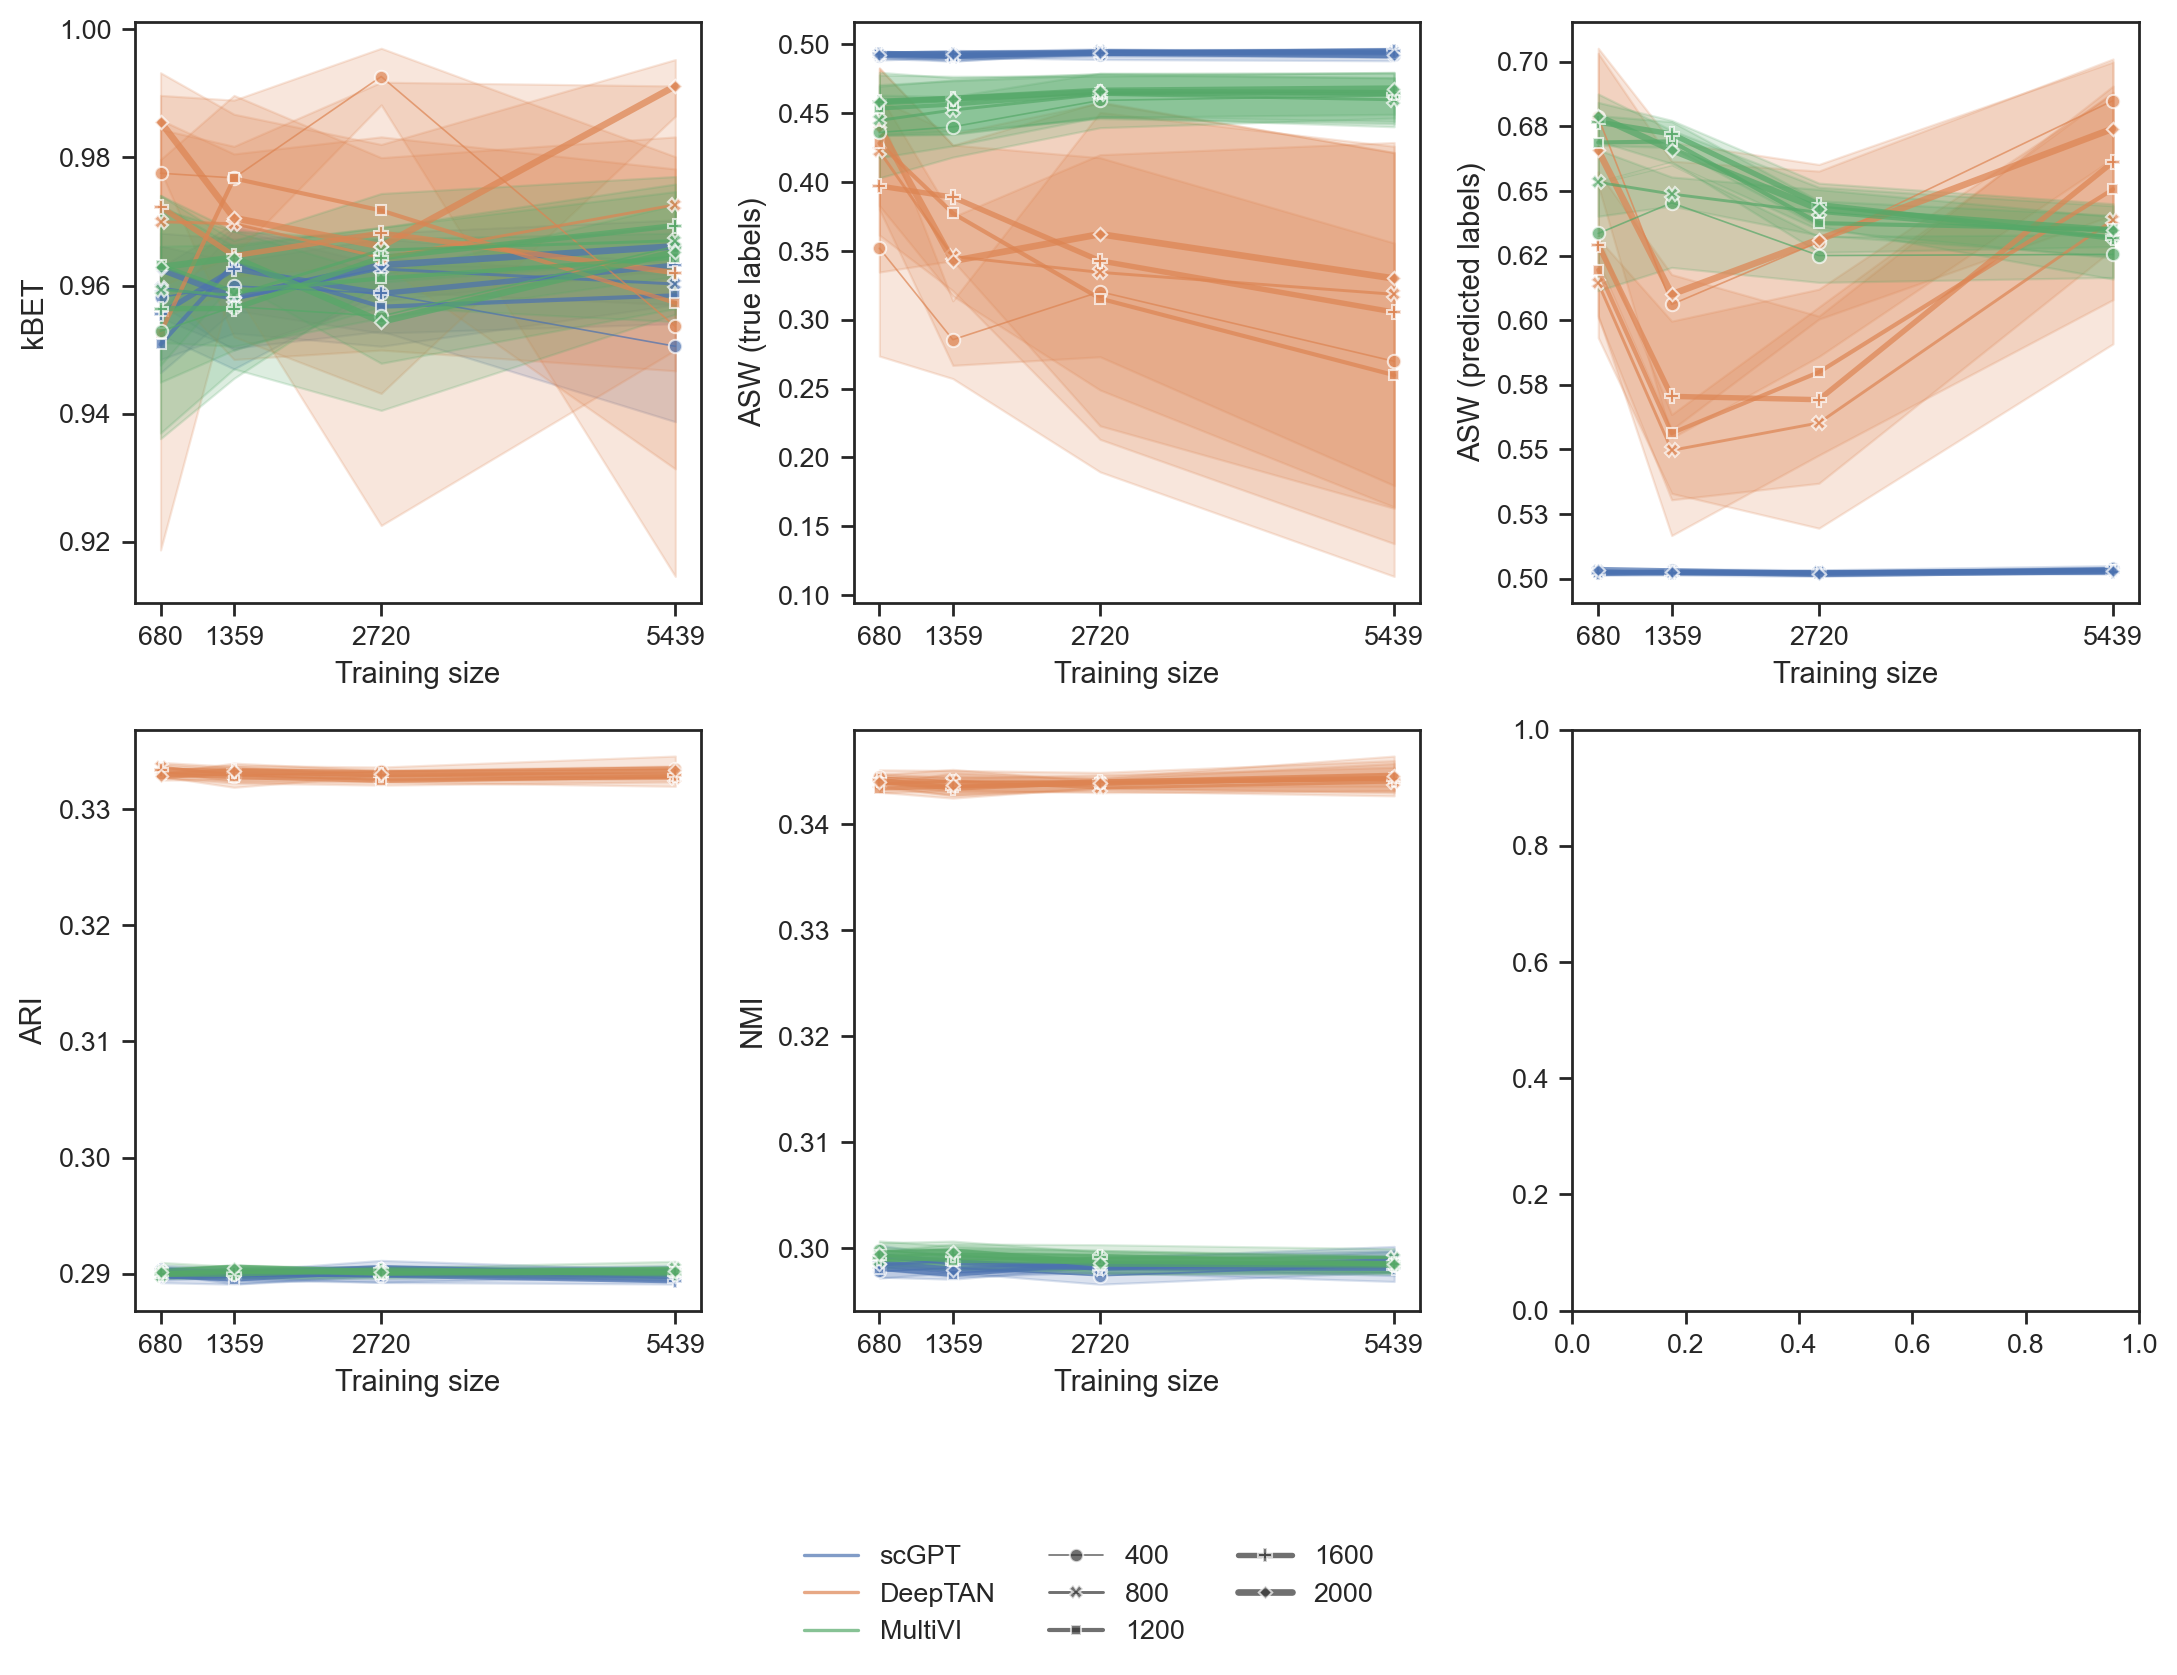

In [82]:
try:
    plt.close("all")
except:
    pass

sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.1)

fig, axes = plt.subplots(2, 3, figsize=(11, 8))

# 将axes展平为一维数组以便迭代
axes = axes.flatten()

# 存储所有线对象用于创建共用图例
handles = []
labels = []

# 为每个指标创建一个子图
for i, metric in enumerate(metrics):
    ax = axes[i]
    _plot = sns.lineplot(
        data=_df.filter(pl.col("dataset") == _dataset),
        x="Train size",
        y=metric,
        hue="Method",
        style="Number of features for test",
        size="Number of features for test",
        dashes=False,
        markers=True,
        alpha=0.7,
        ax=ax,
        # legend=False,
    )

    ax.set_xlabel("Training size")
    ax.set_ylabel(metric)
    ax.set_xticks(_df.filter(pl.col("dataset") == _dataset)["Train size"].unique().sort(descending=True).to_list())

    # 设置刻度格式化器
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))
    # 提取并过滤图例项
    if ax.get_legend():
        legend = ax.get_legend()
        # 获取图例的句柄和标签
        h, l = ax.get_legend_handles_labels()
        # 过滤掉变量名称标题
        filtered = [(handle, label) for handle, label in zip(h, l) if label not in ["Method", "Number of features for test"]]
        # 分离处理后的元素
        filtered_h, filtered_l = zip(*filtered) if filtered else ([], [])
        handles.extend(filtered_h)
        labels.extend(filtered_l)
        # 移除当前子图图例
        legend.remove()
# 去重处理（保持顺序）
seen = set()
unique_handles = []
unique_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)
# 创建共用图例
fig.legend(
    handles=unique_handles,
    labels=unique_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),  # 调整垂直位置
    ncol=3,  # 根据项目数量调整列数
    frameon=False,
    title=None,  # 移除自动生成的标题
)
# 增大底部边距
fig.tight_layout(rect=[0, 0.1, 1, 1])  # 调整rect参数保留底部空间
# fig.tight_layout()

plt.show()

fig.savefig(os.path.join(".fig/", f"{fig_name}.png"), dpi=300)
fig.savefig(os.path.join(".fig/", f"{fig_name}.pdf"))

In [83]:
_dataset = "scmul"
fig_name = f"fig.c3.cluster_metrics.{_dataset}"

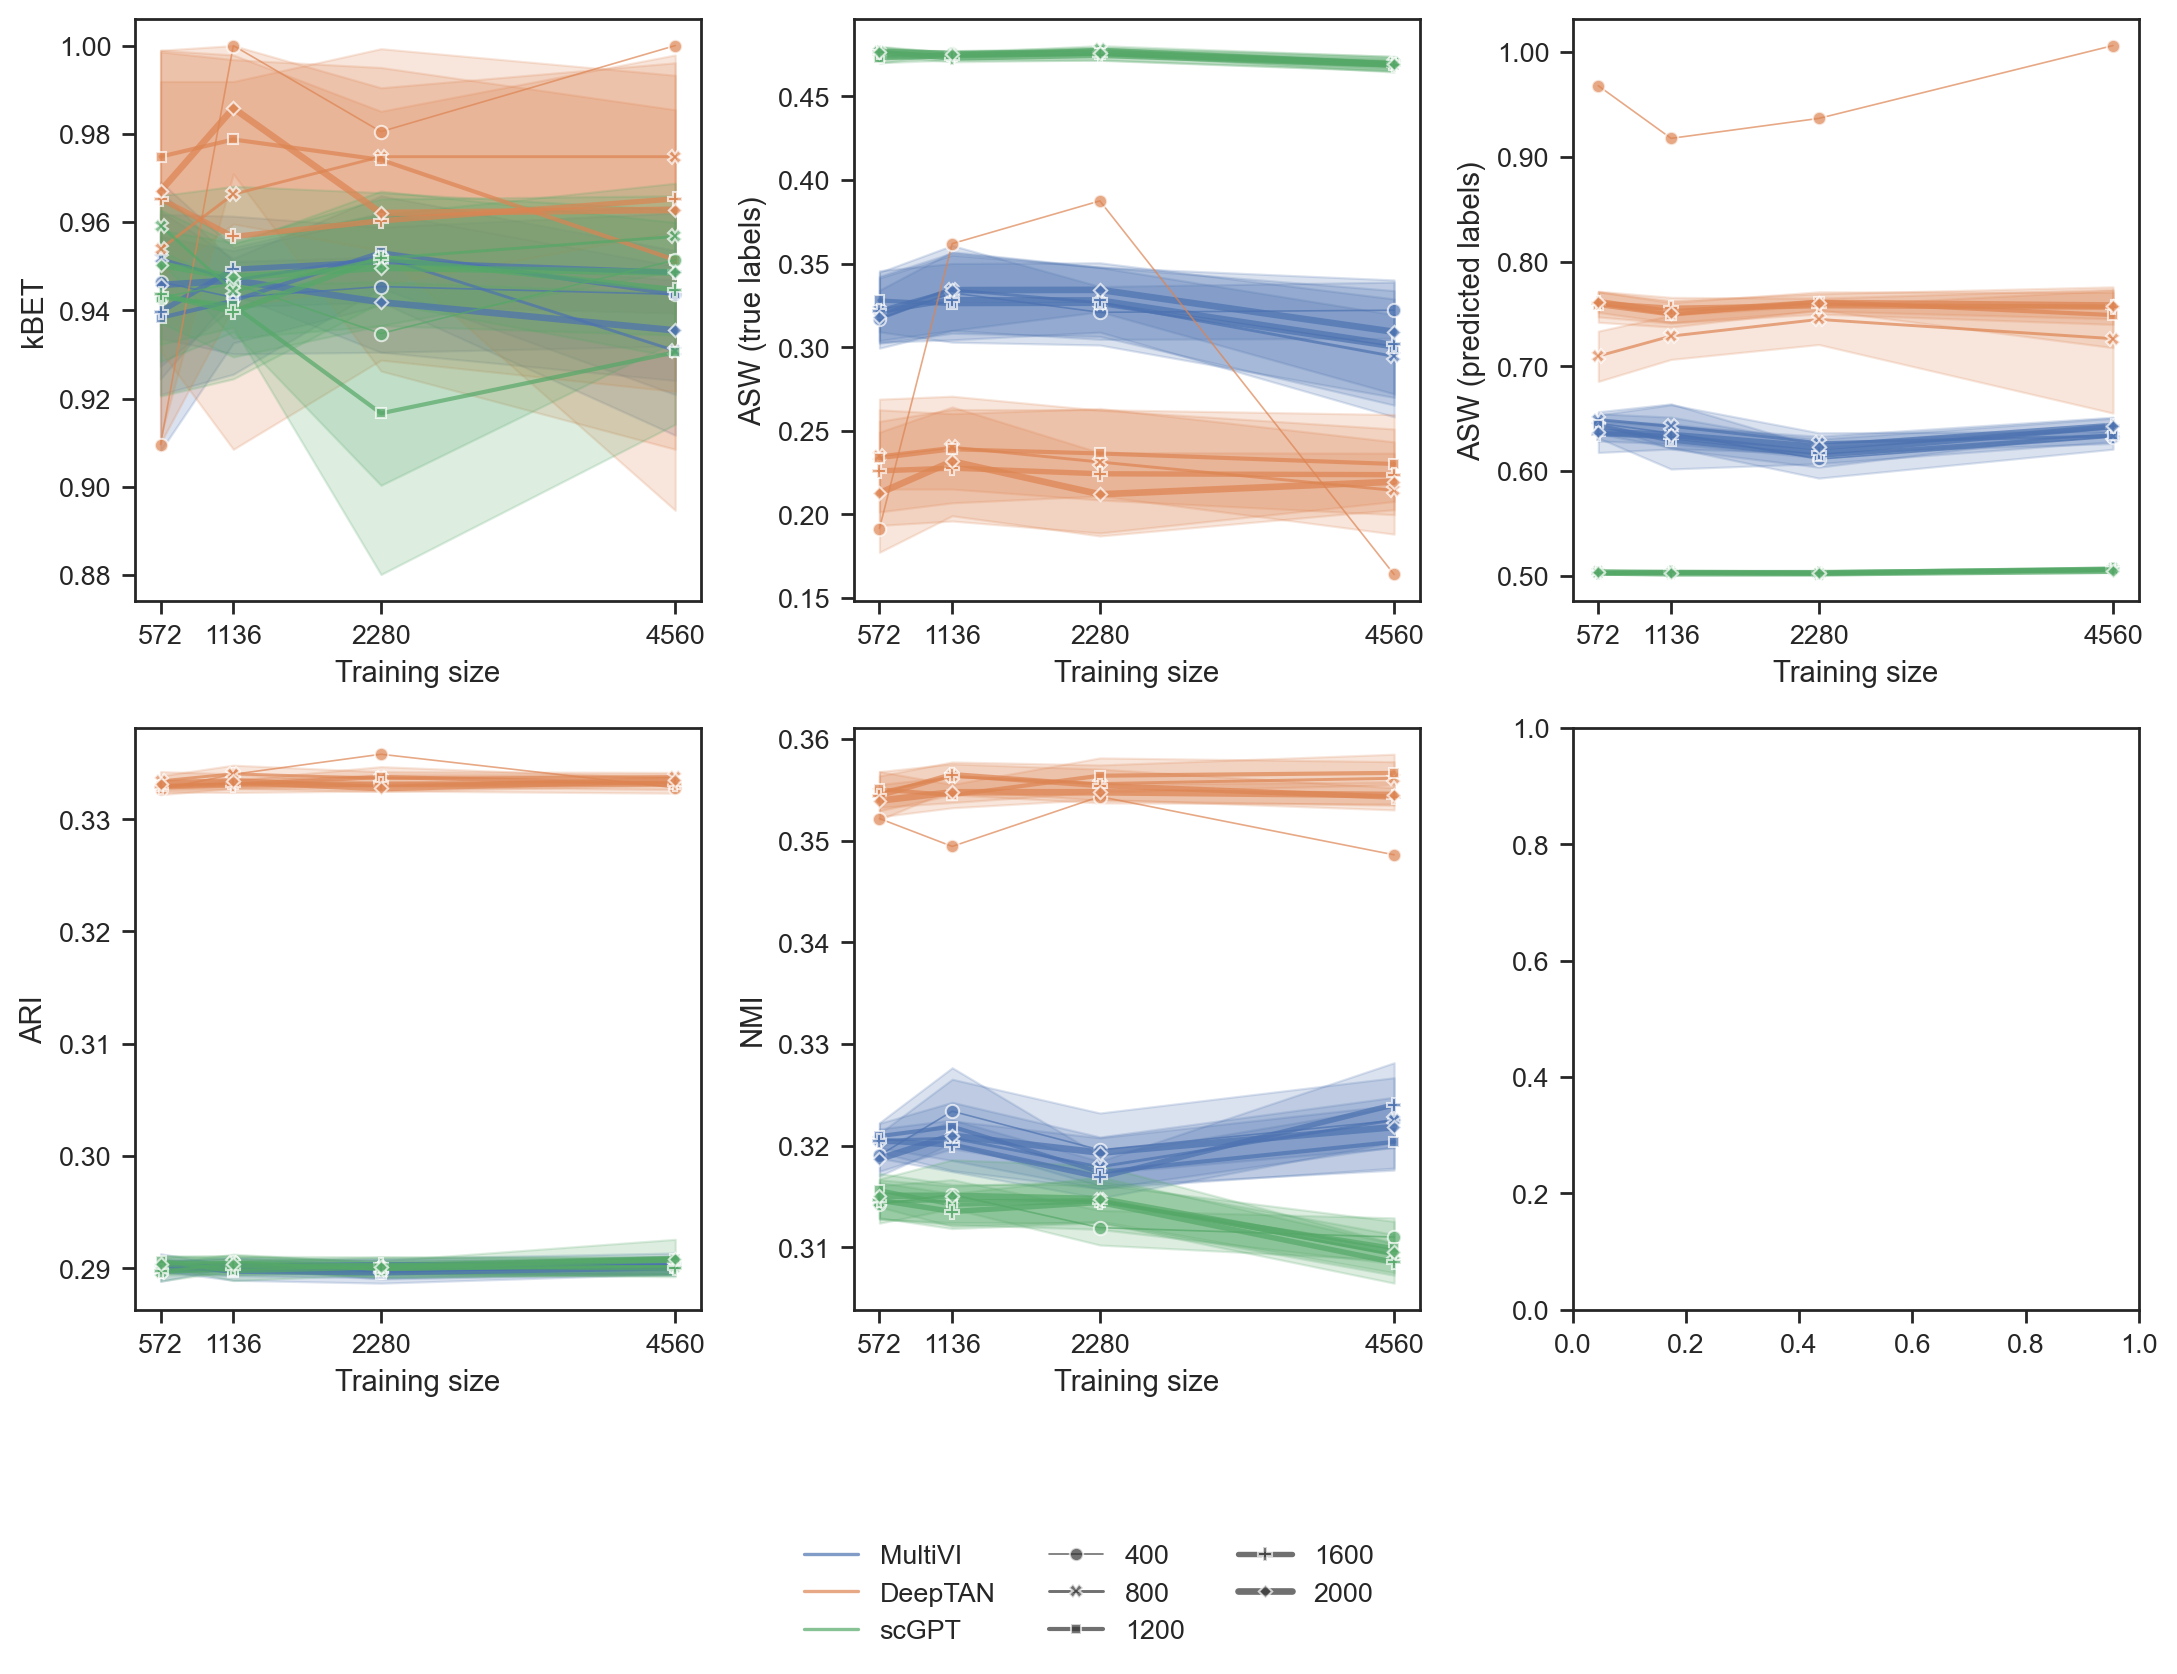

In [84]:
try:
    plt.close("all")
except:
    pass

sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.1)

fig, axes = plt.subplots(2, 3, figsize=(11, 8))

# 将axes展平为一维数组以便迭代
axes = axes.flatten()

# 存储所有线对象用于创建共用图例
handles = []
labels = []

# 为每个指标创建一个子图
for i, metric in enumerate(metrics):
    ax = axes[i]
    _plot = sns.lineplot(
        data=_df.filter(pl.col("dataset") == _dataset),
        x="Train size",
        y=metric,
        hue="Method",
        style="Number of features for test",
        size="Number of features for test",
        dashes=False,
        markers=True,
        alpha=0.7,
        ax=ax,
        # legend=False,
    )

    ax.set_xlabel("Training size")
    ax.set_ylabel(metric)
    ax.set_xticks(_df.filter(pl.col("dataset") == _dataset)["Train size"].unique().sort(descending=True).to_list())

    # 设置刻度格式化器
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))
    # 提取并过滤图例项
    if ax.get_legend():
        legend = ax.get_legend()
        # 获取图例的句柄和标签
        h, l = ax.get_legend_handles_labels()
        # 过滤掉变量名称标题
        filtered = [(handle, label) for handle, label in zip(h, l) if label not in ["Method", "Number of features for test"]]
        # 分离处理后的元素
        filtered_h, filtered_l = zip(*filtered) if filtered else ([], [])
        handles.extend(filtered_h)
        labels.extend(filtered_l)
        # 移除当前子图图例
        legend.remove()
# 去重处理（保持顺序）
seen = set()
unique_handles = []
unique_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)
# 创建共用图例
fig.legend(
    handles=unique_handles,
    labels=unique_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),  # 调整垂直位置
    ncol=3,  # 根据项目数量调整列数
    frameon=False,
    title=None,  # 移除自动生成的标题
)
# 增大底部边距
fig.tight_layout(rect=[0, 0.1, 1, 1])  # 调整rect参数保留底部空间
# fig.tight_layout()

plt.show()

fig.savefig(os.path.join(".fig/", f"{fig_name}.png"), dpi=300)
fig.savefig(os.path.join(".fig/", f"{fig_name}.pdf"))